# Evaluation results
on N=100 per 2 datasets (HuggingFaceH4/MATH-500, ucinlp/drop) with 2 models (Qwen3-0.6B, Deepseek-1.5B) and 2 runs each. Modulated parameters include 4-bit, 8-bit (GPTQ) and $\tau \in$ {64, 128, 256, 512}.

## Setup, data loading, additional features

In [28]:
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scripts.plots import (
    PALETTE, LABEL_MAP, label,
    plot_bars_by_group, plot_benchmark_metrics, plot_regression_scatter,
    plot_score_per_cost, kruskal_dunn, ci_t, _ci_bootstrap, 
)
warnings.filterwarnings("ignore")
save = lambda name: plt.savefig(f'figs/{name}.jpeg', bbox_inches='tight', pad_inches=0.2)
csv_paths = [
    "../2_inference/benchmark_results_005.csv",
    "../2_inference/benchmark_results_004.csv",
]
df = pd.concat([pd.read_csv(p) for p in csv_paths]).dropna()
df["TPT"] = df["mean_req_s"] / (df["thinking_budget"] + 256)
df.head()

,start_time,model,quant_bits,quant_groupsize,thinking_budget,handle,dataset,split,elapsed_s,mean_req_s,power_W,mem_bandwidth_pct,accuracy,f1,ROUGE,METEOR,TPT
0,2026-04-21T10:55:18.360341+02:00,qwen,4,128,64,Qwen/Qwen3-0.6B,hendrycks_math,0,269.947,2.698,60.19,9.82,0.02,0.039216,0.069127,0.053735,0.008431
1,2026-04-21T10:59:52.499473+02:00,qwen,4,128,64,Qwen/Qwen3-0.6B,drop,0,158.862,1.588,62.55,10.31,0.08,0.148148,0.047428,0.047756,0.004962
2,2026-04-21T11:02:31.681753+02:00,qwen,4,128,128,Qwen/Qwen3-0.6B,hendrycks_math,0,308.163,3.081,62.17,9.94,0.00,0.000000,0.047770,0.027131,0.008023
3,2026-04-21T11:07:40.161732+02:00,qwen,4,128,128,Qwen/Qwen3-0.6B,drop,0,174.621,1.745,63.30,10.25,0.07,0.130841,0.048665,0.040706,0.004544
4,2026-04-21T11:10:35.034749+02:00,qwen,4,128,256,Qwen/Qwen3-0.6B,hendrycks_math,0,414.429,4.143,62.59,10.13,0.13,0.230088,0.152265,0.079056,0.008092


## Comparison of scores, quantisation and thinking token counts

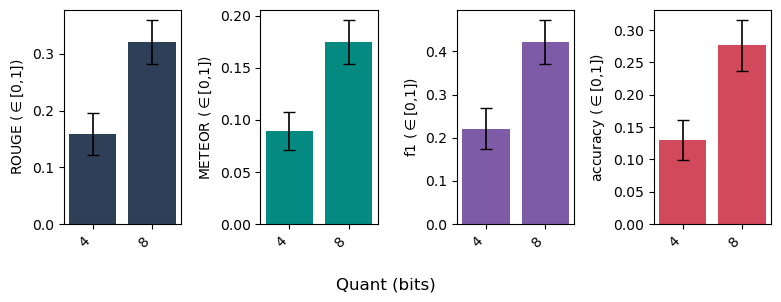

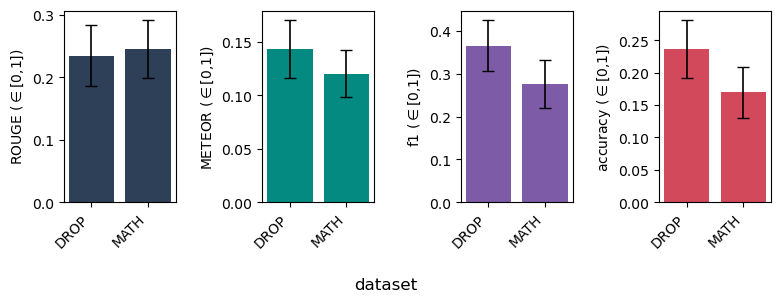

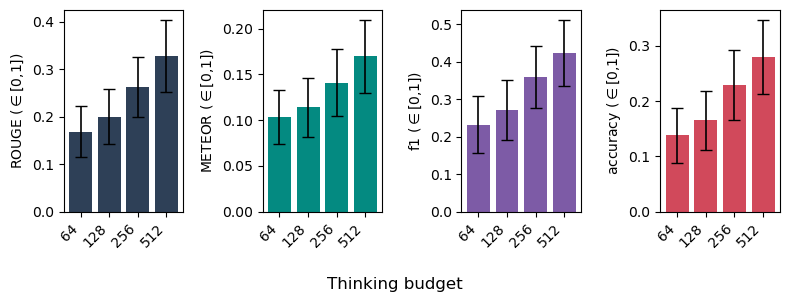

In [7]:
cols = ["ROUGE", "METEOR", "f1", "accuracy"]
groups = ["quant_bits", "dataset", "thinking_budget"]
for group_col, supxlabel, xticklabels in [
    (g, label(g), ["DROP", "MATH"] if g=="dataset" else None) for g in groups
]:
    plot_bars_by_group(
        df, group_col=group_col,
        cols=cols,
        labels=[label(c) for c in cols],
        supxlabel=supxlabel,
        xticklabels=xticklabels,
    )
    save(f"barplot_scores_{group_col}");

## Comparison of compute metrics, quantisation and thinking token counts

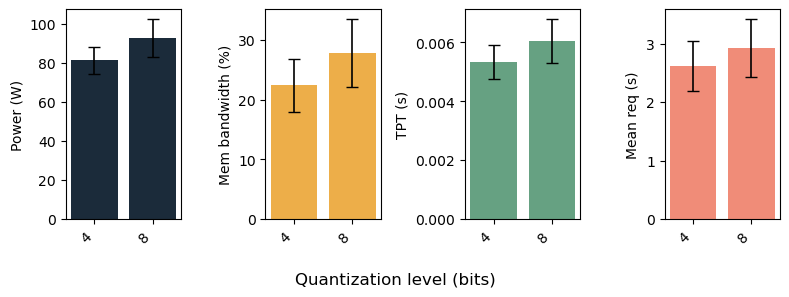

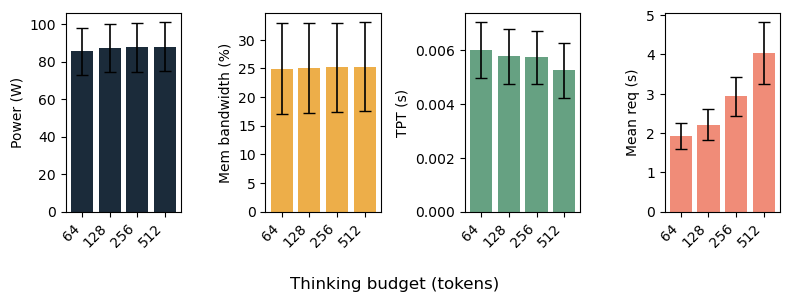

In [8]:
for group_col, supxlabel in [
    ("quant_bits",      "Quantization level (bits)"),
    ("thinking_budget", "Thinking budget (tokens)"),
]:
    plot_bars_by_group(
        df, group_col=group_col,
        cols=["power_W", "mem_bandwidth_pct", "TPT", "mean_req_s"],
        labels=["Power (W)", "Mem bandwidth (%)", "TPT (s)", "Mean req (s)"],
        supxlabel=supxlabel,
        score_range=False,
        palette_start=4,
    );
    save(f"barplot_compute_{group_col}")

## Spearman correlation of features in heatmap

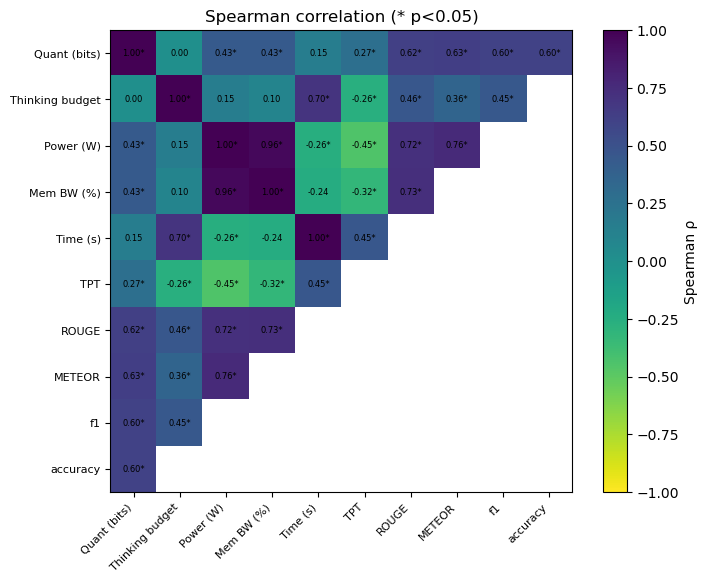

In [9]:
num_cols   = ["quant_bits", "thinking_budget", "power_W", "mem_bandwidth_pct",
              "mean_req_s", "TPT", "ROUGE", "METEOR", "f1", "accuracy"]
col_labels = [label(c) for c in num_cols]
corr  = df[num_cols].corr(method="spearman")
h, w = corr.shape
corr = corr * np.array([[-np.inf if w-x <= y else 1 for y in range(w)] for x in range(h)])
pvals = pd.DataFrame(
    [[stats.spearmanr(df[a], df[b]).pvalue for b in num_cols] for a in num_cols],
    index=num_cols, columns=num_cols,
)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="viridis_r")
plt.colorbar(im, ax=ax, label="Spearman ρ")
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(col_labels, fontsize=8)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        if len(num_cols)-j>i:
            sig = "*" if pvals.iloc[i, j] < 0.05 else ""
            ax.text(j, i, f"{corr.iloc[i,j]:.2f}{sig}", ha="center", va="center", fontsize=6)
ax.set_title("Spearman correlation (* p<0.05)")
save("heatmap_spearman")
plt.show();

## Linear relationship between scores and evaluated configuration parameters

In [10]:
pred_cols = ["quant_bits", "thinking_budget"]
rows = []
for pred_name in pred_cols:
    X = df[pred_name].values.reshape(-1, 1)
    for col in ["ROUGE", "METEOR", "f1", "accuracy"]:
        model = LinearRegression().fit(X, df[col].values)
        rows.append({"predictor": pred_name, "target": col,
                     "coef": round(model.coef_[0], 6),
                     "intercept": round(model.intercept_, 4),
                     "R²": round(model.score(X, df[col].values), 4)})
pd.DataFrame(rows).pivot(index="target", columns="predictor", values=["coef", "R²"])

coef                         R²                
predictor quant_bits thinking_budget quant_bits thinking_budget
target                                                         
METEOR      0.021332        0.000149     0.3859          0.1381
ROUGE       0.040500        0.000350     0.3856          0.2125
accuracy    0.036484        0.000316     0.3678          0.2030
f1          0.050049        0.000421     0.3596          0.1876

In [11]:
rows = []
for pred_name in pred_cols:
    X = df[pred_name].values.reshape(-1, 1)
    for col in ["power_W", "mem_bandwidth_pct", "mean_req_s", "TPT"]:
        model = LinearRegression().fit(X, df[col].values)
        rows.append({"predictor": pred_name, "target": col,
                     "coef": round(model.coef_[0], 6),
                     "intercept": round(model.intercept_, 4),
                     "R²": round(model.score(X, df[col].values), 4)})
pd.DataFrame(rows).pivot(index="target", columns="predictor", values=["coef", "R²"])

coef                         R²                
predictor         quant_bits thinking_budget quant_bits thinking_budget
target                                                                 
TPT                 0.000175       -0.000002     0.0353          0.0204
mean_req_s          0.077008        0.004734     0.0149          0.4138
mem_bandwidth_pct   1.350312        0.000751     0.0361          0.0001
power_W             2.895391        0.004236     0.0612          0.0010

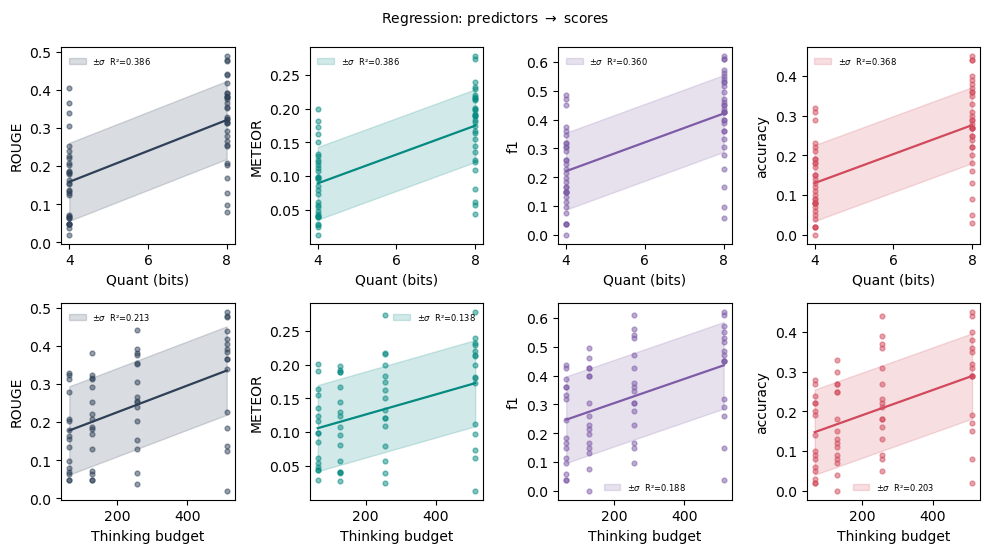

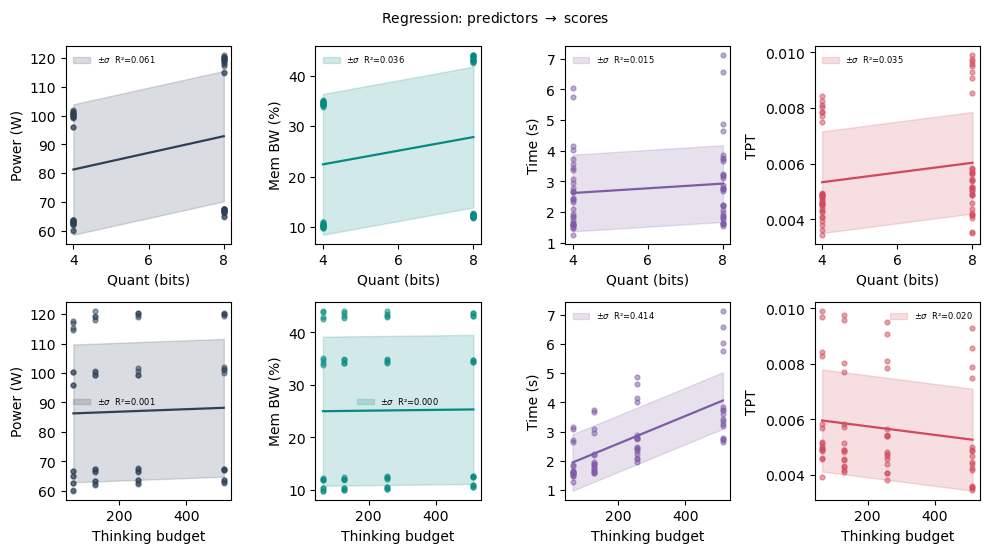

In [12]:
cols = [["ROUGE", "METEOR", "f1", "accuracy"],["power_W", "mem_bandwidth_pct", "mean_req_s", "TPT"]]
n=["scores", "compute"]
for i, cs in enumerate(cols):
    plot_regression_scatter(
    df,
    predictor_cols=["quant_bits", "thinking_budget"],
    target_cols=cs,
    target_labels=[label(c) for c in cs],
    title="Regression: predictors $\\rightarrow$ scores")
    palette_offset=i*4,
    save(f"lin_reg_{n[i]}");

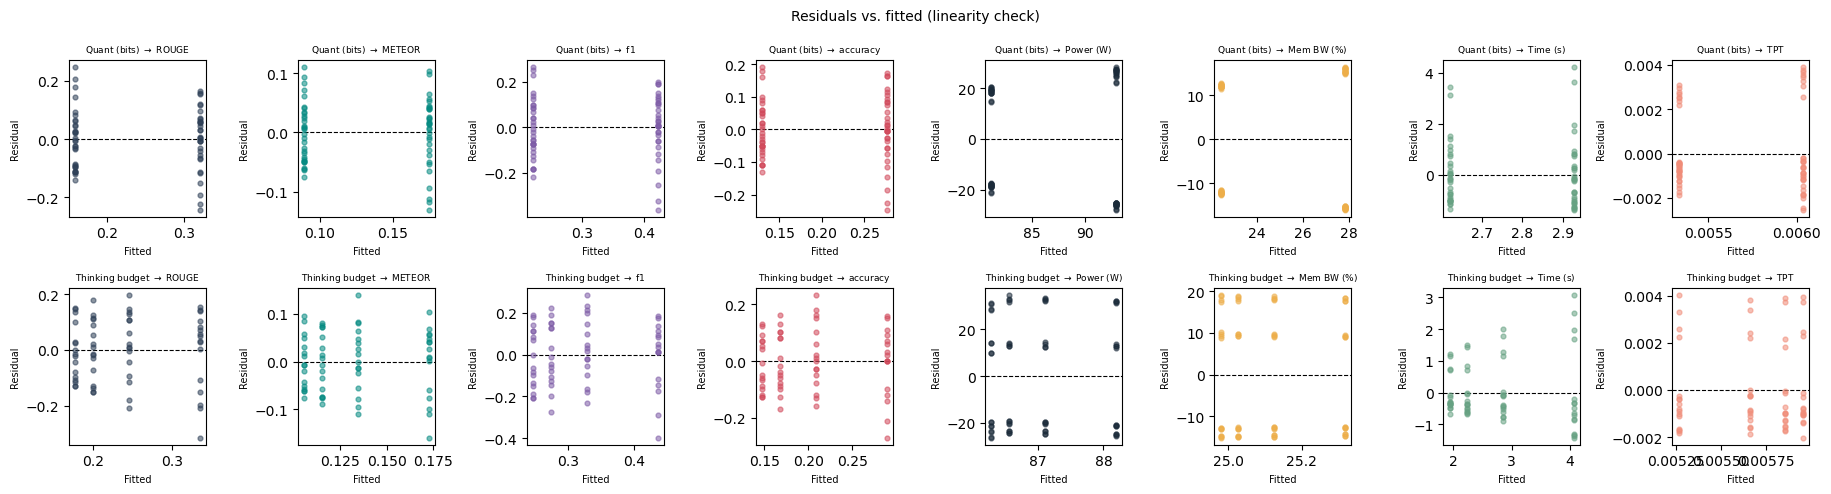

In [13]:
all_targets = ["ROUGE", "METEOR", "f1", "accuracy",
               "power_W", "mem_bandwidth_pct", "mean_req_s", "TPT"]
predictors  = ["quant_bits", "thinking_budget"]
palette     = PALETTE

n_pred, n_tgt = len(predictors), len(all_targets)
fig, axes = plt.subplots(n_pred, n_tgt, figsize=(2.3 * n_tgt, 2.5 * n_pred), squeeze=False)
for r, pred in enumerate(predictors):
    X = df[pred].values.reshape(-1, 1)
    for c, col in enumerate(all_targets):
        ax      = axes[r][c]
        y       = df[col].values
        model   = LinearRegression().fit(X, y)
        fitted  = model.predict(X)
        color   = palette[c % len(palette)]
        ax.scatter(fitted, y - fitted, s=12, alpha=0.55, color=color, zorder=3)
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_xlabel("Fitted", fontsize=7)
        ax.set_ylabel("Residual", fontsize=7)
        ax.set_title(f"{label(pred)} $\\rightarrow$ {label(col)}", fontsize=6.5)
fig.suptitle("Residuals vs. fitted (linearity check)", fontsize=10)
save("lin_reg_residuals")
plt.tight_layout()
plt.show()

## Decomposition of power, memory bandwidth and time per token in 3d space

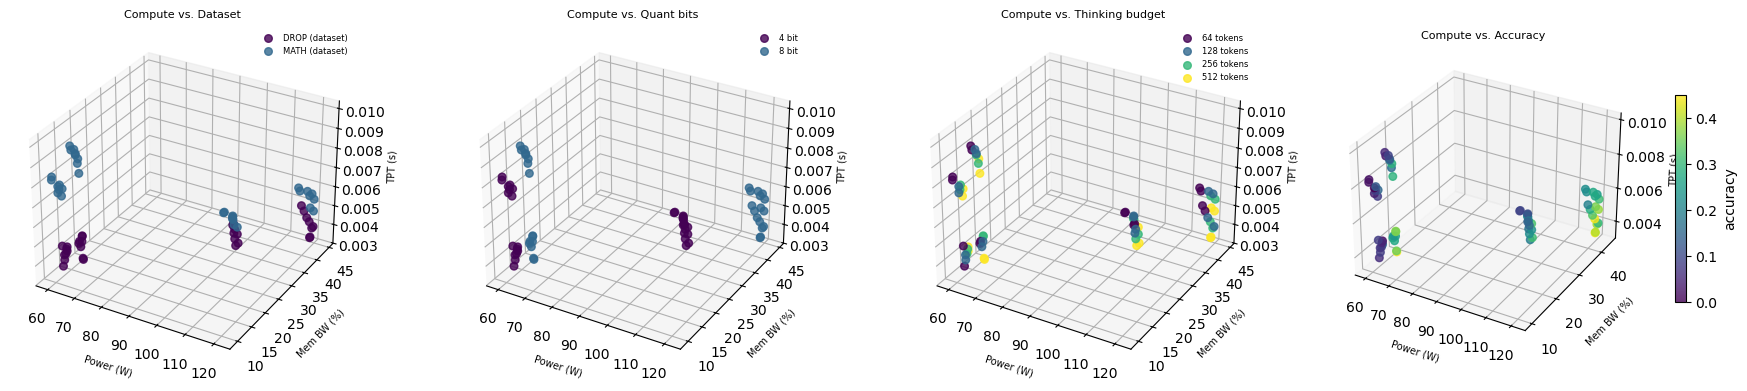

In [14]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(18, 4))
palette=plt.get_cmap("viridis", 4)
# categorical colour splits
for i, (color_col, title, units) in enumerate([
    # ("model",           "Compute vs. Model", " (model)"),
    ("dataset",         "Compute vs. Dataset", " (dataset)"),
    ("quant_bits",      "Compute vs. Quant bits", " bit"),
    ("thinking_budget", "Compute vs. Thinking budget", " tokens"),
]):
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    for j, val in enumerate(sorted(df[color_col].unique())):
        sub = df[df[color_col] == val]
        lab = label(val) + " 0.6b" if units == " (model)" and val == "qwen" else \
        label(val) + " 1.5b" if units == " (model)" and val == "deepseek" else \
        label(val) + units
        ax.scatter(sub.power_W, sub.mem_bandwidth_pct, sub.TPT,
                   color=palette.colors[j], label=lab, s=30, alpha=0.8)
    ax.set_xlabel("Power (W)", fontsize=7)
    ax.set_ylabel("Mem BW (%)", fontsize=7)
    ax.set_zlabel("TPT (s)", fontsize=7)
    ax.set_title(title, fontsize=8)
    ax.legend(fontsize=6, frameon=False)

# 4th dim: accuracy as continuous colour
ax4 = fig.add_subplot(1, 4, 4, projection="3d")
sc  = ax4.scatter(df.power_W, df.mem_bandwidth_pct, df.TPT,
                  c=df.accuracy, cmap="viridis", s=30, alpha=0.8)
fig.colorbar(sc, ax=ax4, label="accuracy", shrink=0.6, pad=0.1)
ax4.set_xlabel("Power (W)", fontsize=7)
ax4.set_ylabel("Mem BW (%)", fontsize=7)
ax4.set_zlabel("TPT (s)", fontsize=7)
ax4.set_title("Compute vs. Accuracy", fontsize=8)
save("3d_decomp_compute")
plt.tight_layout()

## Regression relationships
pruned at 1% standardised influence

In [15]:
targets = {
    "accuracy":          r"\mathrm{accuracy}",
    "power_W":           r"P\;[\mathrm{W}]",
    "mean_req_s":        r"t_{\mathrm{req}}\;[\mathrm{s}]",
    "mem_bandwidth_pct": r"\mathrm{BW}\;[\%]",
}
pred_labels = [r"q", r"\tau"]
X_raw = df[pred_cols].values
X_std = StandardScaler().fit_transform(X_raw)
PRUNE = 0.01

for col, tex_target in targets.items():
    y         = df[col].values
    model     = LinearRegression().fit(X_raw, y)
    model_std = LinearRegression().fit(X_std, y)
    std_coefs = np.abs(model_std.coef_)
    total_inf = std_coefs.sum()
    keep      = (std_coefs / total_inf) >= PRUNE if total_inf > 0 else np.ones(len(pred_cols), bool)

    terms = [
        f"{'+ ' if c >= 0 else '- '}{abs(c):.4f}\\,{l}"
        for l, c, k in zip(pred_labels, model.coef_, keep) if k
    ]
    intercept = model.intercept_
    rhs = " ".join(terms) + f" {'+ ' if intercept >= 0 else '- '}{abs(intercept):.4f}"
    rhs = rhs.lstrip("+ ").strip()

    pruned = [pred_labels[i] for i, k in enumerate(keep) if not k]
    note   = f"  % pruned: {', '.join(['$'+p+'$' for p in pruned])}" if pruned else ""
    print(f"${tex_target} = {rhs}$  ($R^2={model.score(X_raw, y):.3f}$){note}\n")

$\mathrm{accuracy} = 0.0365\,q + 0.0003\,\tau - 0.0915$  ($R^2=0.571$)

$P\;[\mathrm{W}] = 2.8954\,q + 0.0042\,\tau + 68.6475$  ($R^2=0.062$)

$t_{\mathrm{req}}\;[\mathrm{s}] = 0.0770\,q + 0.0047\,\tau + 1.1754$  ($R^2=0.429$)

$\mathrm{BW}\;[\%] = 1.3503\,q + 0.0008\,\tau + 16.8297$  ($R^2=0.036$)



## Scores by dataset, thinking budgets and quantisation level

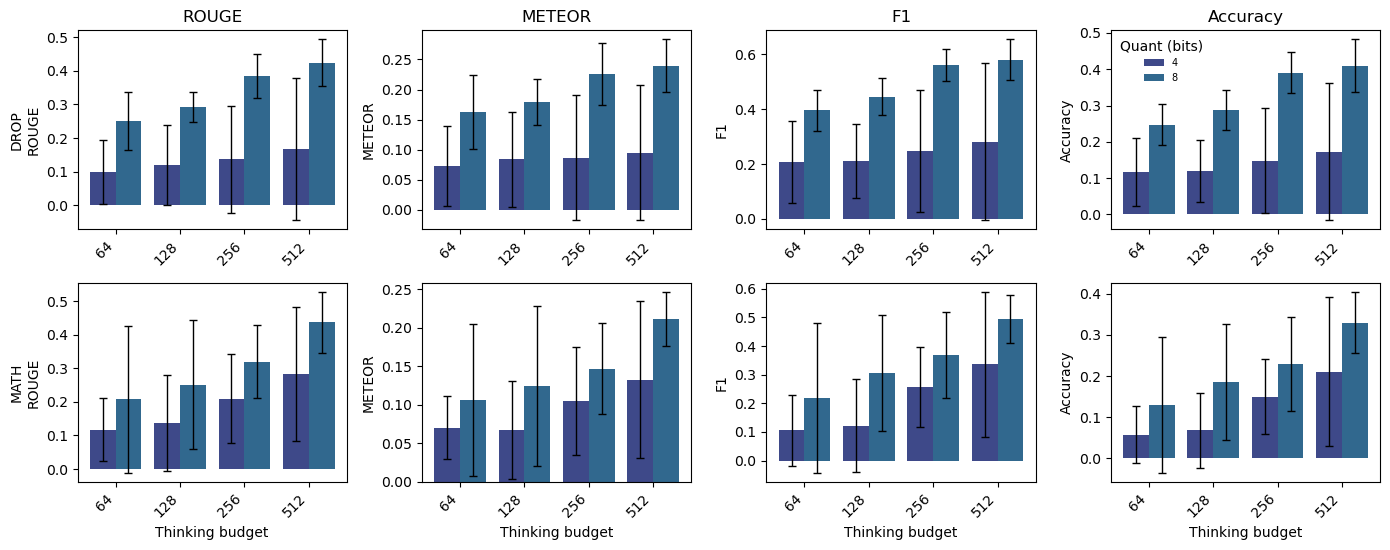

In [17]:
from scripts.plots import plot_scores_faceted
plot_scores_faceted(df, palette=plt.get_cmap("viridis", 10).colors[2:]);
save("bar_scores_datasets")

## Decomposition of scores in 3d space depending on modulated configuration settings

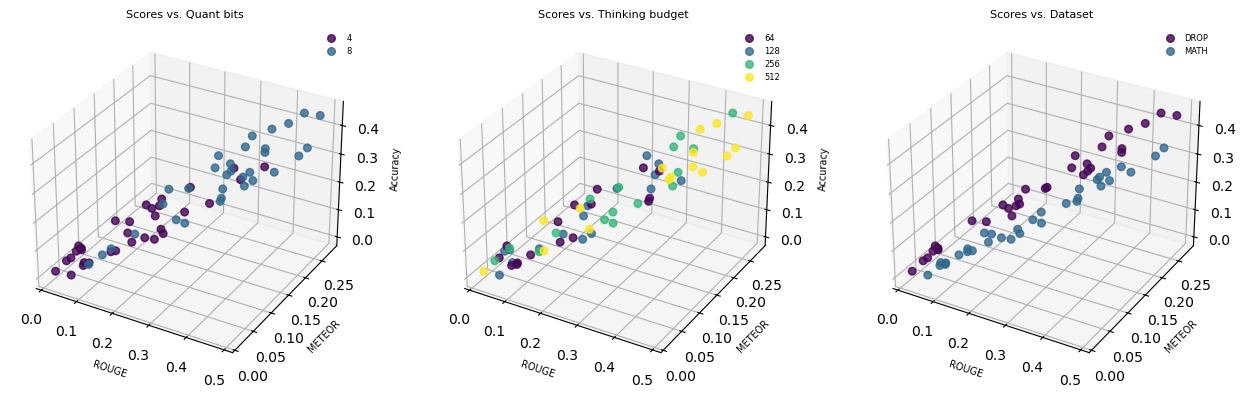

In [18]:
fig = plt.figure(figsize=(13, 4))
palette=plt.get_cmap("viridis", 4)
for i, (color_col, title) in enumerate([
    ("quant_bits",      "Scores vs. Quant bits"),
    ("thinking_budget", "Scores vs. Thinking budget"),
    ("dataset",         "Scores vs. Dataset"),
    # ("model",           "Model")
]):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    for j, val in enumerate(sorted(df[color_col].unique())):
        sub = df[df[color_col] == val]
        ax.scatter(sub.ROUGE, sub.METEOR, sub.accuracy,
                   color=palette.colors[j], label=label(val), s=30, alpha=0.8)
    ax.set_xlabel("ROUGE", fontsize=7)
    ax.set_ylabel("METEOR", fontsize=7)
    ax.set_zlabel("Accuracy", fontsize=7)
    ax.set_title(title, fontsize=8)
    ax.legend(fontsize=6, frameon=False)
save("decomp_scores_3d")
plt.tight_layout()

## Non-parametric tests
because of skewed distributions using Kruskal-Wallis and Dunn

In [19]:
score_cols = ["accuracy", "ROUGE", "METEOR", "f1"]

for predictor in ["quant_bits", "thinking_budget"]:
    print(f"\n{'='*55}\n{label(predictor)}\n{'='*55}")
    for col in score_cols:
        display(kruskal_dunn(df, predictor, col))
        print()


Quant (bits)
Kruskal-Wallis  H=22.938  p=0.0000  (quant_bits → accuracy)


,group_a,group_b,z,p_raw,p_bonferroni,sig
0,4,8,-4.789,0.0,0.0,***



Kruskal-Wallis  H=24.415  p=0.0000  (quant_bits → ROUGE)


,group_a,group_b,z,p_raw,p_bonferroni,sig
0,4,8,-4.941,0.0,0.0,***



Kruskal-Wallis  H=25.218  p=0.0000  (quant_bits → METEOR)


...

,group_a,group_b,z,p_raw,p_bonferroni,sig
0,64,128,-0.712,0.4764,1.0000,ns
1,64,256,-2.041,0.0412,0.2473,ns
2,64,512,-3.399,0.0007,0.0041,**
3,128,256,-1.329,0.1838,1.0000,ns
4,128,512,-2.687,0.0072,0.0433,*
5,256,512,-1.358,0.1746,1.0000,ns



Kruskal-Wallis  H=8.566  p=0.0357  (thinking_budget → METEOR)


,group_a,group_b,z,p_raw,p_bonferroni,sig
0,64,128,-0.342,0.7325,1.0000,ns
1,64,256,-1.415,0.1572,0.9430,ns
2,64,512,-2.649,0.0081,0.0484,*
3,128,256,-1.073,0.2833,1.0000,ns
4,128,512,-2.307,0.0210,0.1263,ns
5,256,512,-1.234,0.2171,1.0000,ns



Kruskal-Wallis  H=12.779  p=0.0051  (thinking_budget → f1)


,group_a,group_b,z,p_raw,p_bonferroni,sig
0,64,128,-0.660,0.5091,1.0000,ns
1,64,256,-2.085,0.0371,0.2223,ns
2,64,512,-3.258,0.0011,0.0067,**
3,128,256,-1.425,0.1542,0.9250,ns
4,128,512,-2.598,0.0094,0.0562,ns
5,256,512,-1.173,0.2407,1.0000,ns


## Bootstrapped CIs vs. t-interval CIs

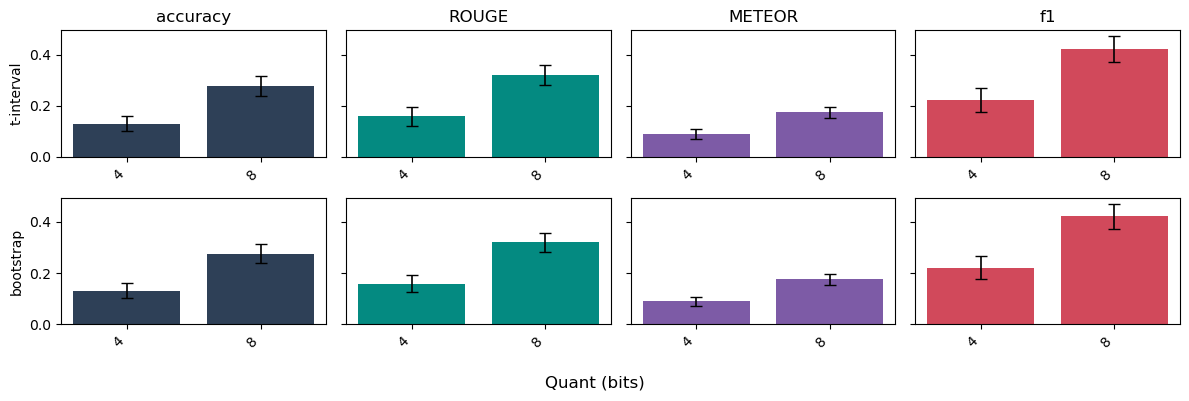

In [20]:
fig, axs = plt.subplots(2, len(score_cols), figsize=(3 * len(score_cols), 4), sharey="row")
groups = sorted(df.quant_bits.unique())
x = np.arange(len(groups))

for c, col in enumerate(score_cols):
    slices = [df[df.quant_bits == g][col] for g in groups]
    means  = [s.mean() for s in slices]
    for row, (ci_fn, ci_lbl) in enumerate([
        (ci_t,           "t-interval"),
        (_ci_bootstrap, "bootstrap"),
    ]):
        ax = axs[row][c]
        cis = [ci_fn(s) for s in slices]
        ax.bar(x, means, color=PALETTE[c], yerr=cis, capsize=4,
               error_kw={"linewidth": 1.2})
        ax.set_xticks(x); ax.set_xticklabels(groups, rotation=45, ha="right")
        if c == 0:
            ax.set_ylabel(ci_lbl)
        if row == 0:
            ax.set_title(col)
save("bars_cost")
fig.supxlabel(label("quant_bits"))
plt.tight_layout()

## Marginal cost analysis difference for modulated parameters

In [21]:
X = df[["quant_bits", "thinking_budget"]].values
a_q, a_tau = LinearRegression().fit(X, df["accuracy"].values).coef_
p_q, p_tau = LinearRegression().fit(X, df["power_W"].values).coef_

print(f"Marginal accuracy per quant bit :  {a_q:.5f}")
print(f"Marginal accuracy per token     :  {a_tau:.5f}")
print(f"Tokens equivalent to 1 quant bit:  {a_q/a_tau:.1f} tokens\n")
print(f"Power cost per accuracy unit via quant : {p_q/a_q:.4f} W / $\delta$acc")
print(f"Power cost per accuracy unit via tokens: {p_tau/a_tau:.4f} W / $\delta$acc")
print(f"\n$\\rightarrow$ Matching accuracy via quant bits costs {(p_q/a_q)/(p_tau/a_tau):.2f}× "
      f"{'more' if (p_q/a_q) > (p_tau/a_tau) else 'less'} power than via thinking tokens\n")

rows = []
for dt in [64, 128, 256, 512, 1024]:
    da   = a_tau * dt;  dq = da / a_q
    dp_t = p_tau * dt;  dp_q = p_q * dq
    rows.append({"$\delta$ thinking tokens": dt, "$\delta$ accuracy": round(da, 4),
                 "Equiv. $\delta$ quant bits": round(dq, 2),
                 "Power via tokens (W)": round(dp_t, 4), "Power via quant (W)": round(dp_q, 4),
                 "Power ratio (q/τ)": round(dp_q / dp_t, 2)})
pd.DataFrame(rows).set_index("$\delta$ thinking tokens")

Marginal accuracy per quant bit :  0.03648
Marginal accuracy per token     :  0.00032
Tokens equivalent to 1 quant bit:  115.5 tokens

Power cost per accuracy unit via quant : 79.3597 W / $\delta$acc
Power cost per accuracy unit via tokens: 13.4053 W / $\delta$acc

$\rightarrow$ Matching accuracy via quant bits costs 5.92× more power than via thinking tokens



,$\delta$ accuracy,Equiv. $\delta$ quant bits,Power via tokens (W),Power via quant (W),Power ratio (q/τ)
$\delta$ thinking tokens,,,,,
64,0.0202,0.55,0.2711,1.6049,5.92
128,0.0404,1.11,0.5422,3.2098,5.92
256,0.0809,2.22,1.0844,6.4195,5.92
512,0.1618,4.43,2.1687,12.8390,5.92
1024,0.3236,8.87,4.3375,25.6781,5.92


In [29]:
a_q, a_tau = LinearRegression().fit(X, df["accuracy"].values).coef_
t_q, t_tau = LinearRegression().fit(X, df["mean_req_s"].values).coef_

print(f"Time cost per accuracy unit via quant : {t_q/a_q:.4f} s / $\delta$acc")
print(f"Time cost per accuracy unit via tokens: {t_tau/a_tau:.4f} s / $\delta$acc")
print(f"\n$\\rightarrow$ Matching accuracy via quant bits costs {(t_q/a_q)/(t_tau/a_tau):.2f}× "
      f"{'more' if (t_q/a_q) > (t_tau/a_tau) else 'less'} time than via thinking tokens\n")

rows = []
for dt in [64, 128, 256, 512, 1024]:
    da   = a_tau * dt;  dq = da / a_q
    dt_t = t_tau * dt;  dt_q = t_q * dq
    rows.append({"$\delta$ thinking tokens": dt, "$\delta$ accuracy": round(da, 4),
                 "Equiv. $\delta$ quant bits": round(dq, 2),
                 "Time via tokens (s)": round(dt_t, 4), "Time via quant (s)": round(dt_q, 4),
                 "Time ratio (q/τ)": round(dt_q / dt_t, 2)})
pd.DataFrame(rows).set_index("$\delta$ thinking tokens")

Time cost per accuracy unit via quant : 2.1107 s / $\delta$acc
Time cost per accuracy unit via tokens: 14.9822 s / $\delta$acc

$\rightarrow$ Matching accuracy via quant bits costs 0.14× less time than via thinking tokens



,$\delta$ accuracy,Equiv. $\delta$ quant bits,Time via tokens (s),Time via quant (s),Time ratio (q/τ)
$\delta$ thinking tokens,,,,,
64,0.0202,0.55,0.3030,0.0427,0.14
128,0.0404,1.11,0.6060,0.0854,0.14
256,0.0809,2.22,1.2119,0.1707,0.14
512,0.1618,4.43,2.4239,0.3415,0.14
1024,0.3236,8.87,4.8477,0.6830,0.14


## Interaction effect: quant_bits $\times$ thinking_budget
Does higher reasoning budget help more at lower quantisation levels?

In [ ]:
df["interaction"] = df["quant_bits"] * df["thinking_budget"]

score_cols = ["accuracy", "ROUGE", "METEOR", "f1"]
rows = []
for col in score_cols:
    y = df[col].values

    # without interaction
    X_base = df[["quant_bits", "thinking_budget"]].values
    m_base = LinearRegression().fit(X_base, y)
    r2_base = m_base.score(X_base, y)

    # with interaction
    X_int = df[["quant_bits", "thinking_budget", "interaction"]].values
    m_int = LinearRegression().fit(X_int, y)
    r2_int = m_int.score(X_int, y)

    coef_q, coef_tau, coef_ix = m_int.coef_
    rows.append({
        "metric":        col,
        "coef_q":        round(coef_q,   6),
        "coef_τ":        round(coef_tau, 6),
        "coef_q×τ":      round(coef_ix, 8),
        "intercept":     round(m_int.intercept_, 4),
        "R² (base)":     round(r2_base, 4),
        "R² (+interact)":round(r2_int,  4),
        "ΔR²":           round(r2_int - r2_base, 4),
    })

pd.DataFrame(rows).set_index("metric")

,coef_q,coef_τ,coef_q×τ,intercept,R² (base),R² (+interact),ΔR²
metric,,,,,,,
accuracy,0.027609,0.000094,0.000037,-0.0382,0.5708,0.5819,0.0111
ROUGE,0.029652,0.000079,0.000045,-0.0224,0.5981,0.6123,0.0141
METEOR,0.015136,-0.000006,0.000026,0.0055,0.5240,0.5407,0.0166
f1,0.041956,0.000219,0.000034,-0.0316,0.5472,0.5520,0.0048


Low interaction found, $\rightarrow$ linear breakeven calculation

## Breakeven analysis: tokens needed to compensate 8-bit → 4-bit accuracy loss

In [ ]:
from scripts.analysis import plot_breakeven
plot_breakeven(df, save)

Result: When balancing 8-bit from 64 budgets to 4 bit, 526 tokens are required (with increased power and time).

## Tradeoff between score and costs

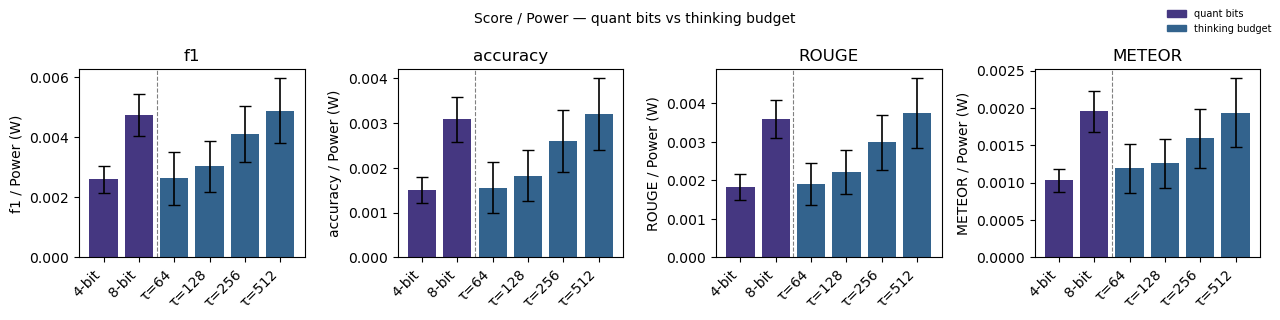

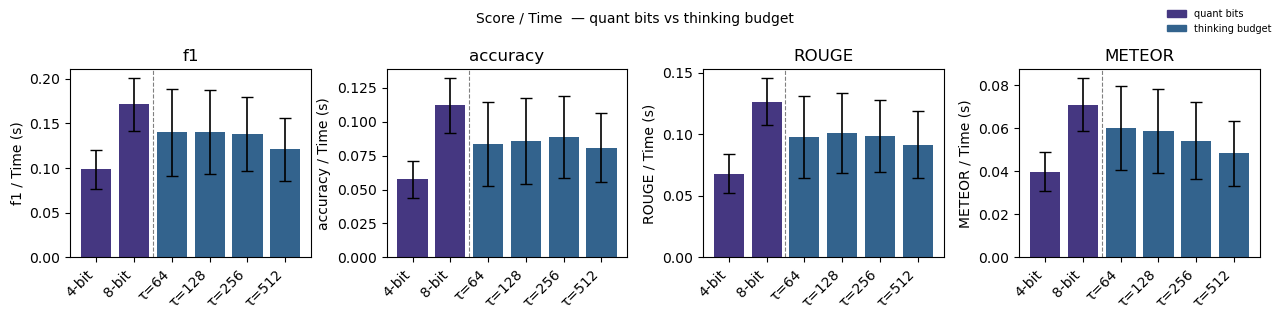

In [25]:
plot_score_per_cost(df, "power_W",    "Power (W)", "Score / Power — quant bits vs thinking budget", palette=plt.get_cmap("viridis", 20).colors[2:])
save("bars_score_per_time")
plot_score_per_cost(df, "mean_req_s", "Time (s)",  "Score / Time  — quant bits vs thinking budget", palette=plt.get_cmap("viridis", 20).colors[2:])
save("bars_score_per_power")

## Rainfall plots for metrics, error bars, and benchmarked configurations
Adopted from past publication

Saved → figs/benchmark_metrics_half.png
Saved → figs/benchmark_metrics_full.png
Saved → figs/benchmark_metrics_slide.png


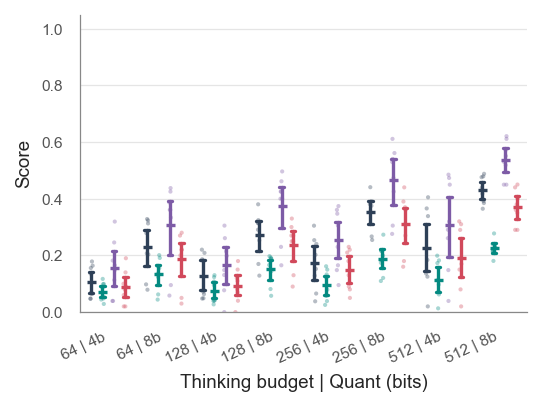

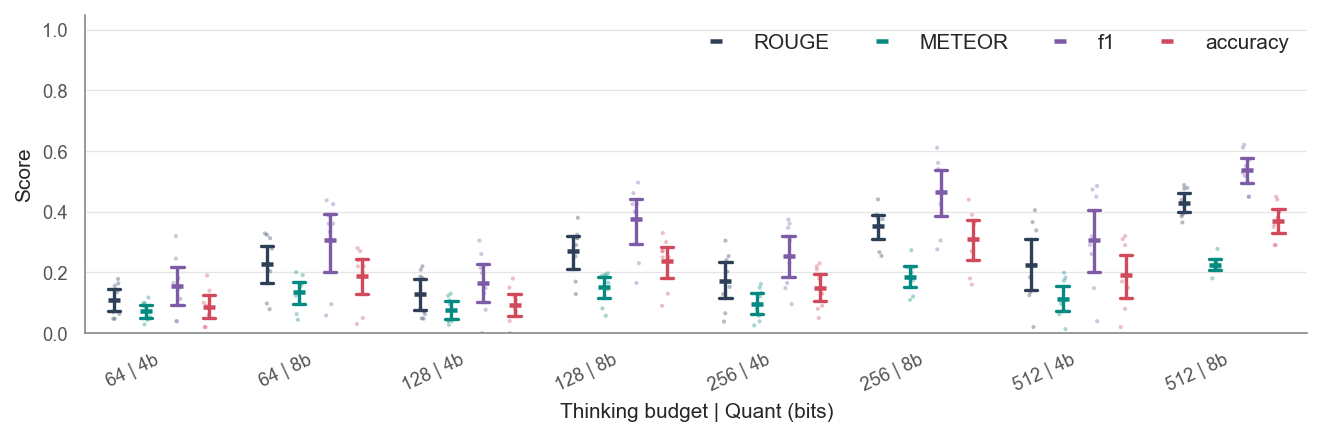

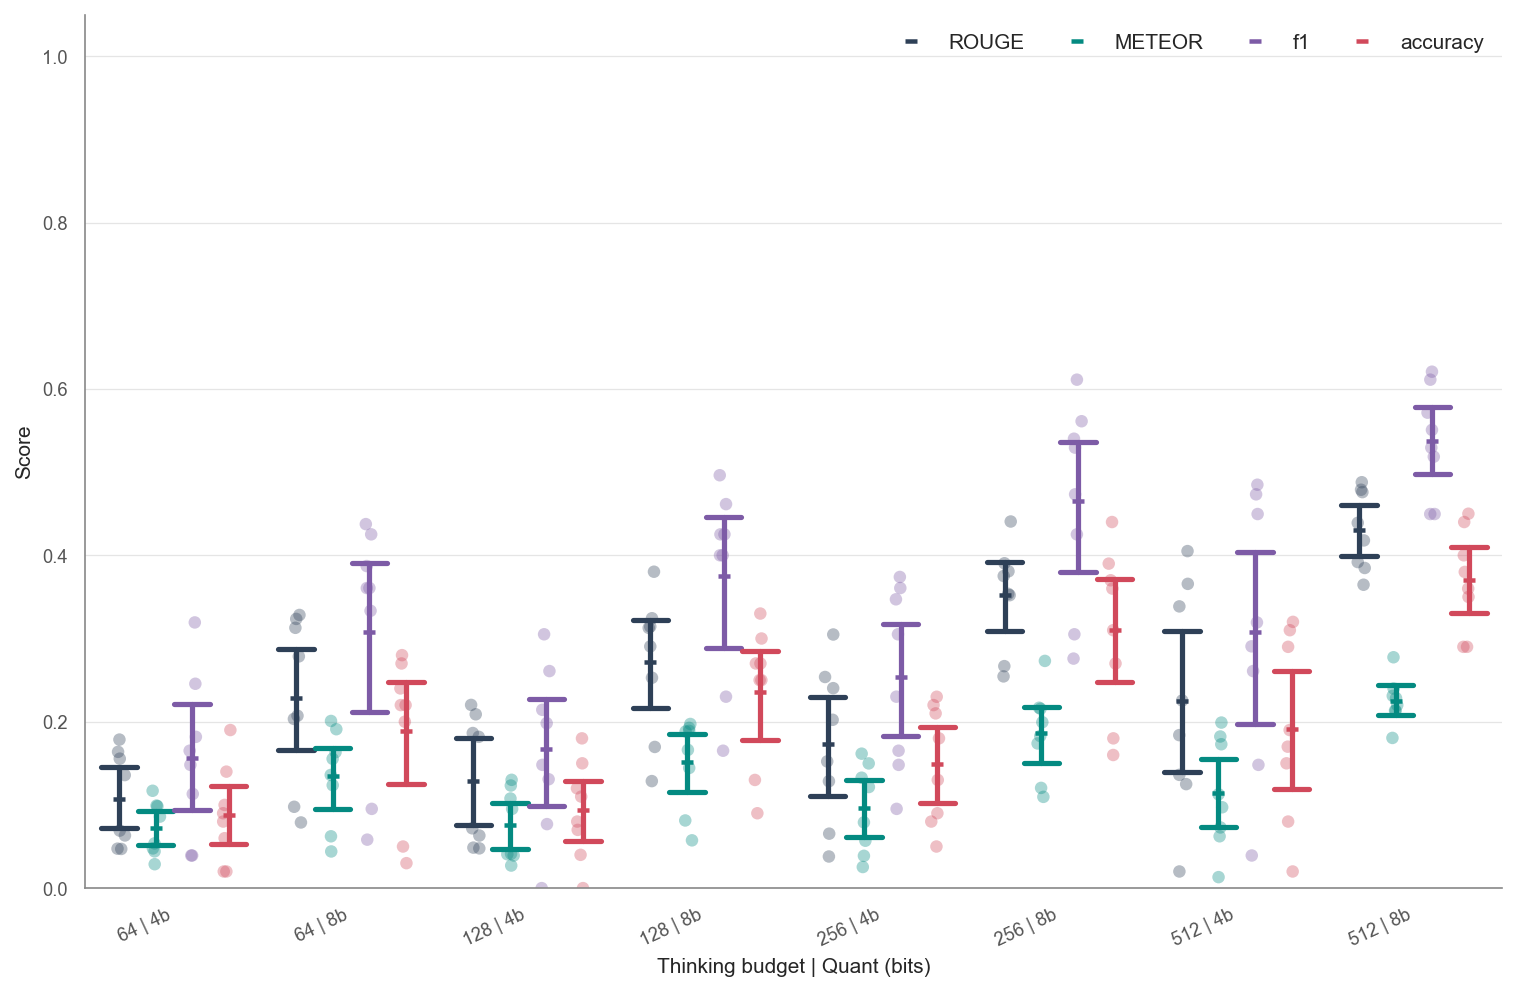

In [26]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
for mode in ["half", "full", "slide"]:
    plot_benchmark_metrics(
        df,
        metrics=["ROUGE", "METEOR", "f1", "accuracy"],
        group_by="thinking_budget",
        hue_var="quant_bits",
        title="",
        mode=mode,
        save_path=f"figs/benchmark_metrics_{mode}.png",
    )